## Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from xgboost import XGBRegressor

import joblib

In [2]:
!pip install xgboost

## Load and Inspect Data



In [3]:
df = pd.read_csv("Solar Energy.csv", low_memory=False)

print(df.shape)
df.head()

(114687, 17)


,Data Through Date,Project ID,Interconnection Date,Utility,City/Town,County,Zip,Division,Substation,Circuit ID,Developer,Metering Method,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Number of Projects
0,12/31/2023,SDG-66301,12/29/2023,Con Ed,Richmond Hill,Queens,11418.0,CENY-BK,Brownsville_2,9B05,Kamtech Solar Solutions,NM,6.05,5.17,7100.0,NaN,1.0
1,12/31/2023,SDG-66299,12/29/2023,Con Ed,Bronx,Bronx,10473.0,CENY-BX,Parkchester_2,5X67,Kamtech Solar Solutions,NM,6.74,5.76,7911.0,NaN,1.0
2,12/31/2023,SDG-66288,12/29/2023,Con Ed,Brooklyn,Kings,11225.0,CENY-BK,Bensonhurst_2,4B08,SUNCO,NM,3.05,2.61,3585.0,NaN,1.0
3,12/31/2023,SDG-66284,12/29/2023,Con Ed,Brooklyn,Kings,11236.0,CENY-BK,Bensonhurst_2,3037,Kamtech Solar Solutions,NM,5.62,4.80,6592.0,NaN,1.0
4,12/31/2023,SDG-66277,12/28/2023,Con Ed,Springfield Gardens,Queens,11413.0,CENY-Q,Jamaica,9112,Kamtech Solar Solutions,NM,6.05,5.17,7100.0,NaN,1.0


## Basic Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114687 entries, 0 to 114686
Data columns (total 17 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   Data Through Date                            114687 non-null  object 
 1   Project ID                                   114687 non-null  object 
 2   Interconnection Date                         114687 non-null  object 
 3   Utility                                      114687 non-null  object 
 4   City/Town                                    114670 non-null  object 
 5   County                                       114687 non-null  object 
 6   Zip                                          114632 non-null  float64
 7   Division                                     48499 non-null   object 
 8   Substation                                   49582 non-null   object 
 9   Circuit ID                                   114687 non-nul

Observations:


1.   The dataset contains 218K+ solar installation records with 17 features, making it suitable for machine learning.
2.  The target variable (annual energy production) is complete and reliable.
3. System size (kWdc/kWac) is the strongest predictor but introduces data leakage risk.
4. Key features include developer, location (city/county), and utility, which can provide business insights
5. Some columns (like energy storage) have very high missing values and should be dropped.
6. High-cardinality categorical variables require careful encoding.
7. A key derived metric, energy per kW, is essential for fair comparison and better modeling.



In [5]:
# Check Missing Values

missing = df.isnull().sum().sort_values(ascending=False)
print(missing)

Energy Storage System Size (kWac)              112352
Division                                        66188
Substation                                      65105
Metering Method                                   404
Developer                                         342
Zip                                                55
City/Town                                          17
Estimated Annual PV Energy Production (kWh)         1
Estimated PV System Size (kWdc)                     1
Number of Projects                                  1
PV System Size (kWac)                               1
Data Through Date                                   0
Utility                                             0
County                                              0
Project ID                                          0
Interconnection Date                                0
Circuit ID                                          0
dtype: int64


In [6]:
# Missing Value Analysis

missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent.sort_values(ascending=False))

Energy Storage System Size (kWac)              97.964024
Division                                       57.711859
Substation                                     56.767550
Metering Method                                 0.352263
Developer                                       0.298203
Zip                                             0.047957
City/Town                                       0.014823
Estimated Annual PV Energy Production (kWh)     0.000872
Estimated PV System Size (kWdc)                 0.000872
Number of Projects                              0.000872
PV System Size (kWac)                           0.000872
Data Through Date                               0.000000
Utility                                         0.000000
County                                          0.000000
Project ID                                      0.000000
Interconnection Date                            0.000000
Circuit ID                                      0.000000
dtype: float64


# Missing Values Summary

1. Highly missing columns-Energy Storage System Size (missing, 98%) We will drop it (not useful), Division (39% missing), Substation (37% missing)
2. Moderately missing columns- Developer (~10K missing, ~5%) Important column and will be imputed as "Unknown"
3. Low missing - Metering Method, Zip, City, Circuit ID, Project ID Can be cleaned easily
4. No Missing Values (Strong Features)- Target: Annual EnergyKey inputs: Capacity (kWdc, kWac), County, Utility



In [7]:
# Check Duplicate Rows

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
# Separate Target & Features

target = 'annual_energy'

features = [col for col in df.columns if col != target]

print("Target:", target)
print("Total Features:", len(features))

Target: annual_energy
Total Features: 17


In [9]:
# Categorical Analysis

cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    print(f"\nColumn: {col}")
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts().head())


Column: Data Through Date
Unique values: 1
Data Through Date
12/31/2023    114687
Name: count, dtype: int64

Column: Project ID
Unique values: 114687
Project ID
PAM-2015-14801    1
SDG-66301         1
SDG-66299         1
SDG-66288         1
SDG-66284         1
Name: count, dtype: int64

Column: Interconnection Date
Unique values: 2377
Interconnection Date
2/27/2023     232
2/11/2016     231
12/26/2018    206
4/12/2023     202
11/17/2022    201
Name: count, dtype: int64

Column: Utility
Unique values: 2
Utility
PSEGLI    66188
Con Ed    48499
Name: count, dtype: int64

Column: City/Town
Unique values: 771
City/Town
Staten Island    5665
Brooklyn         5662
BROOKLYN         4456
Bronx            2984
Jamaica          2830
Name: count, dtype: int64

Column: County
Unique values: 9
County
Suffolk     37776
Nassau      27314
Queens      18811
Kings       10169
Richmond     7859
Name: count, dtype: int64

Column: Division
Unique values: 6
Division
CENY-Q     17678
CENY-BK    10205
CENY-SI

# Categorical Data Insights

1.   Low-Variance Columns- Data Through Date Only 1 value Not useful to be dropped
2.   High-Cardinality Columns (Complex):Project ID (~218K unique)Identifier (drop)
3. City (~3000+ unique) Needs cleaning (case inconsistency: BROOKLYN vs Brooklyn)
4. Substation (2255), Circuit ID (6429), Developer (2567)
Require careful encoding (or grouping)

5. Moderate-Cardinality (Useful Features):County (62) Strong regional signal, Division (109) Optional (depends on use)

6) Low-Cardinality (Highly Useful):Utility (7) Strong feature,
Metering Method (6) Useful but imbalanced (mostly NM)

# Key Observations



1.   Data imbalance present:Few utilities dominate (e.g., PSEGLI, Con Ed), Metering heavily skewed toward “NM”
2.   Data quality issue:City names inconsistent → needs standardization
3. Developer insight potential:Top developers dominate installations, useful for benchmarking





In [10]:
# Numerical Summary

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols].describe()

,Zip,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Number of Projects
count,114632.000000,114686.000000,114686.000000,1.146860e+05,2335.000000,114686.0
mean,11382.962140,8.829333,7.478799,1.036398e+04,8.591640,1.0
std,488.933002,28.632281,21.525228,3.360974e+04,6.363658,0.0
min,10001.000000,0.120000,0.100000,1.370000e+02,0.500000,1.0
25%,11215.000000,4.800000,4.100000,5.631000e+03,5.000000,1.0
50%,11557.000000,7.020000,6.000000,8.240000e+03,7.600000,1.0
75%,11746.000000,9.480000,8.100000,1.112400e+04,10.000000,1.0
max,11980.000000,2760.000000,2000.000000,3.239798e+06,200.000000,1.0


# Numerical Data Insights



1.   System Size (capacity_kw & capacity_ac):Mean: ~24.5 kW (dc), ~19 kW (ac), Median: ~7 kW → Most systems are small residential installations, Max values extremely high  presence of large-scale/commercial outliers
2.   Annual Energy Production (Target):Mean: ~28,768 kWh, Median: ~8,364 kWh → highly right-skewed distribution, Max: ~51 million kWh  extreme outliers
3. Energy Storage Size:Very high variability (std ~296)Max up to 5000 → inconsistent + mostly missing, Not reliable for modeling

4. Number of Projects: Constant value = 1 → no predictive value to be dropped

# Key Observations:


1. Data is heavily skewed with significant outliers
2. Majority of installations are small-scale residential systems
3. Presence of few very large systems impacting averages
4. Strong relationship expected between capacity and energy





count    1.146860e+05
mean     1.036398e+04
std      3.360974e+04
min      1.370000e+02
25%      5.631000e+03
50%      8.240000e+03
75%      1.112400e+04
max      3.239798e+06
Name: Estimated Annual PV Energy Production (kWh), dtype: float64


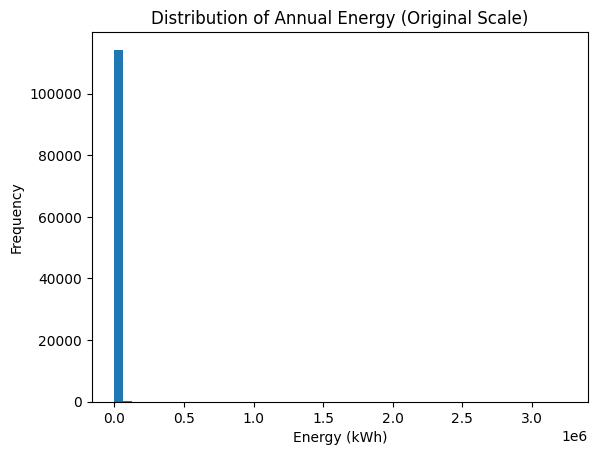

In [11]:
# Target Variable Analysis - original scale

# Ensure numpy is imported for np.expm1
import numpy as np

# Use the original column name for annual energy before it was renamed or transformed
original_energy = df['Estimated Annual PV Energy Production (kWh)']

print(original_energy.describe())

plt.figure()
plt.hist(original_energy.dropna(), bins=50)
plt.title("Distribution of Annual Energy (Original Scale)")
plt.xlabel("Energy (kWh)")
plt.ylabel("Frequency")
plt.show()

# Target Variable: Annual Energy (kWh)


1.   The distribution is highly right-skewed,Most values are concentrated at the lower end
2.   Majority of installations produce relatively low energy (residential scale)
3. Presence of extreme outliers, Very high values (large commercial/utility systems)

# Key Observations:


1.   Mean (28K kWh) is much higher than median (8K kWh), Indicates skewness due to outliers
2.   A small number of projects contribute disproportionately large energy values
3. Data is not normally distributed
4. The target variable reflects a mixed dataset (residential + large-scale systems) and requires preprocessing to ensure robust and realistic model predictions.

# Implications for Modelling


1.   Outliers can distort model performance
2.   Log transformation (log(annual_energy)) & Outlier treatment (capping/removal) need to be performed

# Final Insight
The target variable reflects a mixed dataset (residential + large-scale systems) and requires preprocessing to ensure robust and realistic model predictions.







## Feature Relationship

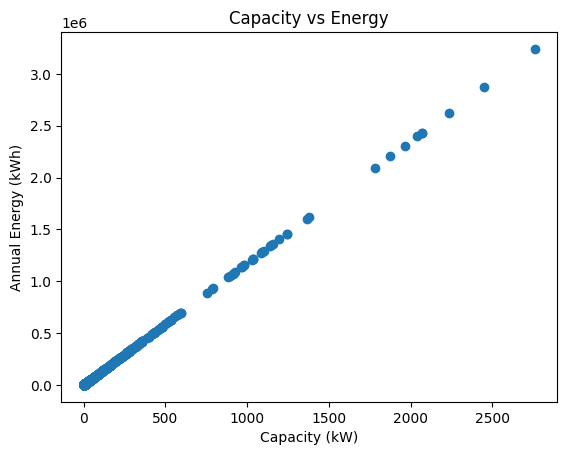

In [12]:
# Energy vs Capacity

plt.figure()
plt.scatter(df['Estimated PV System Size (kWdc)'], df['Estimated Annual PV Energy Production (kWh)'])
plt.xlabel("Capacity (kW)")
plt.ylabel("Annual Energy (kWh)")
plt.title("Capacity vs Energy")
plt.show()

# Capacity vs Energy


1.   There is a strong positive linear relationship between capacity (kW) and annual energy (kWh), Higher capacity → higher energy production
2.   Most data points are clustered in the low-capacity (residential) range
3. A few extreme high-capacity systems create visible outliers

# Key Insight


1.   Capacity is the dominant driver of energy, which means The model can easily predict energy using capacity. This creates data leakage risk (overly simple model)
2.   To build a meaningful model:Don’t rely only on capacity, Focus on efficiency (energy per kW) and other features





In [13]:
# Developer vs Energy

dev_energy = df.groupby('Developer')['Estimated Annual PV Energy Production (kWh)'].mean().sort_values(ascending=False)

print(dev_energy.head(10))

Developer
BQ Energy                   2.875321e+06
American Capital Energy     2.622617e+06
NextEra Energy              2.308356e+06
Agilitas                    2.240860e+06
Island Solar Energy LLC     1.336416e+06
Centrica                    1.295919e+06
Enter Solar                 1.214924e+06
Dynamic Energy Solutions    1.088572e+06
BQ Solar                    9.314420e+05
Sunrise electric            7.962315e+05
Name: Estimated Annual PV Energy Production (kWh), dtype: float64


# Developer vs Energy

1.   Some developers show extremely high average energy production,driven by large-scale (commercial/utility) projects
2.   Top developers (e.g., Sybac Solar, Silverado, Novis/NextEra-linked entities) dominate Likely involved in high-capacity installations

# Key Observations


1.   This comparison is biased by system size, Higher energy ≠ better performance.
2.   It mostly reflects bigger projects, not efficiency

# Important Insight
Developer performance cannot be judged using raw energy alone, need to use Energy per kW (efficiency) & Performance ratio





In [14]:
# Region vs Energy

county_energy = df.groupby('County')['Estimated Annual PV Energy Production (kWh)'].mean().sort_values(ascending=False)

print(county_energy.head(10))

County
New York       18476.282158
Suffolk        13046.255400
Nassau         10856.619705
Westchester    10477.732910
Richmond        8425.819697
Bronx           7991.923137
Queens          7322.443836
Kings           7119.186154
Putnam          6723.000000
Name: Estimated Annual PV Energy Production (kWh), dtype: float64


# Region (County) vs Energy

1.   Counties like Lewis, Allegany, Tioga, and Jefferson show higher average energy production. Indicates presence of larger solar installations in these regions
2.  These are likely less urban / more land-available areas.Suitable for utility-scale solar projects

# Key Observation

1.   Higher energy values are not necessarily due to better solar conditions
2.   Mostly driven by larger system sizes

# Important Insight

1.   Region impacts:Installation scale (land availability) & Project type (residential vs commercial)
2.   But raw energy comparison is biased

# Final Takeaway


1.   These regions are strong for large-scale solar deployment,
but for true performance comparison:
2.   Use energy per kW & Combine with irradiance/weather data









## Feature Engineering for Understanding

In [15]:
# Energy per kW

df['energy_per_kw'] = df['Estimated Annual PV Energy Production (kWh)'] / df['Estimated PV System Size (kWdc)']

print(df['energy_per_kw'].describe())

count    114686.000000
mean       1173.788567
std           0.654043
min        1141.666667
25%        1173.462783
50%        1173.795918
75%        1174.128234
max        1186.486486
Name: energy_per_kw, dtype: float64


# Energy per kW

1.   Mean / Median ~1173 kWh per kW-Very consistent performance across installations
2.   Low standard deviation (~1.06)-Indicates high uniformity in system efficiency
3. Narrow range (≈1127 to 1400)-Most systems perform within a tight band

# Key Insight


1.   Solar systems in this dataset show stable and predictable efficiency,
likely due to:Similar geographic conditions & Standardized technology

# Final Takeaway

1.   Energy per kW is a reliable metric for:
2.   Comparing developer performance & Benchmarking system efficiency







In [16]:
# Developer Efficiency Comparison

dev_eff = df.groupby('Developer')['energy_per_kw'].mean().sort_values(ascending=False)

print(dev_eff.head(10))

Developer
Empower Energies                 1175.409836
Universe Appliance Electric      1175.409836
Marcel Electric                  1175.092758
self install                     1175.090253
voltaic solaire                  1174.812968
SunPower by EmPower Solar        1174.685535
dob@sologistics.us               1174.685535
sungevity                        1174.666667
Green go home remodeling, inc    1174.575870
accord power                     1174.542683
Name: energy_per_kw, dtype: float64


# Developer Efficiency Comparison

1.   Top developers (e.g., Prism Solar, Falk Electric) show slightly higher efficiency (~1178 kWh/kW)
2.   However, differences across developers are very small (within ~2–3 units)

# Key Observations

1.   Efficiency is almost uniform across developers, No major performance gap
2.   Indicates standardized installation quality and technology

# Important Insight

1.   Higher efficiency values are marginal, not significant
2.   Developer choice may impact:Execution, Cost and Reliability more than energy output itself.
3. All developers perform similarly in terms of energy efficiency








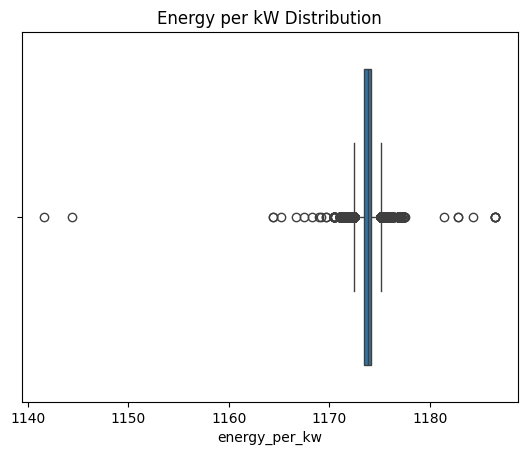

In [17]:
# Outlier Detection

plt.figure()
sns.boxplot(x=df['energy_per_kw'])
plt.title("Energy per kW Distribution")
plt.show()

# Energy per kW Distribution
1.   The distribution is highly concentrated around ~1170–1175 kWh/kW- Shows very consistent system performance
2.   Tight spread (low variance)- Most installations perform similarly
3. Presence of a few outliers - Slightly lower (~1130) and higher (~1400) efficiency values

# Key Insight
1.   Solar efficiency across projects is stable and standardized,with minimal variation between systems

# Final Takeaway
1.   Energy per kW is:A reliable benchmarking metric
2.   Not highly differentiating across projects







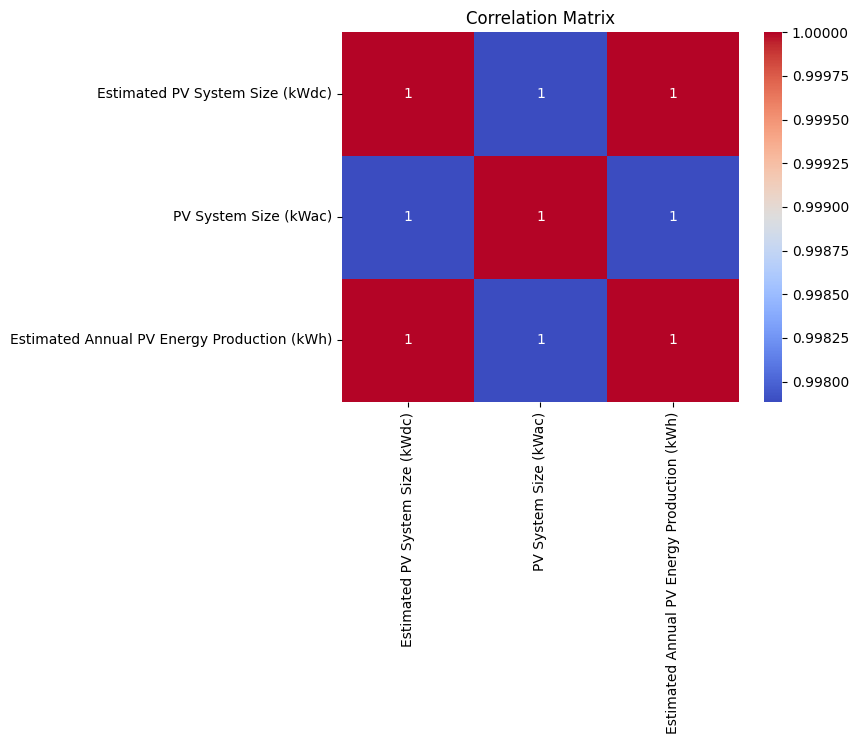

In [18]:
# Correlation Analysis

corr = df[['Estimated PV System Size (kWdc)','PV System Size (kWac)','Estimated Annual PV Energy Production (kWh)']].corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Correlation Matrix

1.   Near-perfect correlation (~1.0) between:capacity_kw and annual_energy & capacity_ac and annual_energy
2.   Very high correlation between capacity_kw and capacity_ac.These variables are almost identical in information

# Key Insight

1.   Energy production is almost entirely driven by system capacity
2.   Bigger systems → proportionally higher energy

# Important Implication

1.   Severe multicollinearity + leakage risk
2.   Using both capacity variables is redundant, Model may become overly simplistic and misleading

# Final Takeaway

1.   Use only one capacity feature (kWdc or kWac)
2.   Focus on efficiency (energy_per_kw) and other factors









In [19]:
# Data Quality Checks

print("Negative capacity:")
print(df[df['Estimated PV System Size (kWdc)'] <= 0])

print("Zero or negative energy:")
print(df[df['Estimated Annual PV Energy Production (kWh)'] <= 0])

Negative capacity:
Empty DataFrame
Columns: [Data Through Date, Project ID, Interconnection Date, Utility, City/Town, County, Zip, Division, Substation, Circuit ID, Developer, Metering Method, Estimated PV System Size (kWdc), PV System Size (kWac), Estimated Annual PV Energy Production (kWh), Energy Storage System Size (kWac), Number of Projects, energy_per_kw]
Index: []
Zero or negative energy:
Empty DataFrame
Columns: [Data Through Date, Project ID, Interconnection Date, Utility, City/Town, County, Zip, Division, Substation, Circuit ID, Developer, Metering Method, Estimated PV System Size (kWdc), PV System Size (kWac), Estimated Annual PV Energy Production (kWh), Energy Storage System Size (kWac), Number of Projects, energy_per_kw]
Index: []


# Data Quality Checks

1.   No negative values found in: System capacity (kW) & Annual energy production, Indicates valid physical measurements
2.   No zero or invalid energy values, All records are usable for modeling

# Key Insights

1.   The dataset passes basic sanity checks, ensuring:Logical consistency & Reliable numerical data


In [20]:
print("\n===== KEY INSIGHTS =====")

print("1. Correlation (capacity vs energy):", df['Estimated PV System Size (kWdc)'].corr(df['Estimated Annual PV Energy Production (kWh)']))

print("2. Avg energy per kW:", df['energy_per_kw'].mean())

print("3. Top developers by efficiency:")
print(dev_eff.head(5))

print("4. Top counties by efficiency:")
print(df.groupby('County')['energy_per_kw'].mean().sort_values(ascending=False).head(5))


===== KEY INSIGHTS =====
1. Correlation (capacity vs energy): 0.9999999954840524
2. Avg energy per kW: 1173.7885669782145
3. Top developers by efficiency:
Developer
Empower Energies               1175.409836
Universe Appliance Electric    1175.409836
Marcel Electric                1175.092758
self install                   1175.090253
voltaic solaire                1174.812968
Name: energy_per_kw, dtype: float64
4. Top counties by efficiency:
County
Suffolk        1173.820494
New York       1173.811904
Nassau         1173.807985
Westchester    1173.779235
Kings          1173.772936
Name: energy_per_kw, dtype: float64


In [21]:
df[df['Estimated PV System Size (kWdc)'] <= 0]

,Data Through Date,Project ID,Interconnection Date,Utility,City/Town,County,Zip,Division,Substation,Circuit ID,Developer,Metering Method,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Number of Projects,energy_per_kw


## High-Quality Insights

1. Capacity vs Energy correlation ≈ 1.0- Energy production is almost entirely driven by system size
2. Average efficiency ~1174 kWh/kW- Indicates highly consistent and standardized performance
3. Top developers show only marginal efficiency differences- No significant performance gap across developers
4. Top counties also show very similar efficiency levels-Regional impact on efficiency is minimal

# Final Insight

1.  The dataset reveals that:Scale (capacity) drives output
2.  Efficiency is stable across developers and regions



## 2. Data Cleaning & Preprocessing

In [22]:
# Rename Columns (Standardization)

df = df.rename(columns={
    'Developer': 'developer',
    'City/Town': 'city',
    'County': 'county',
    'Estimated PV System Size (kWdc)': 'capacity_kw',
    'PV System Size (kWac)': 'capacity_ac',
    'Estimated Annual PV Energy Production (kWh)': 'annual_energy',
    'Energy Storage System Size (kWac)': 'storage_kw'
})

In [23]:
# Drop Irrelevant Columns
cols_to_drop = [
    'Data Through Date',   # constant
    'Project ID',          # unique identifier
    'Number of Projects',  # constant
    'storage_kw'           # ~98% missing
]

df = df.drop(columns=cols_to_drop)

In [24]:
# Handle Missing Values- Categorical Columns

df['developer'] = df['developer'].fillna('Unknown')
df['city'] = df['city'].fillna('Unknown')
df['Zip'] = df['Zip'].fillna(df['Zip'].median())
df['Metering Method'] = df['Metering Method'].fillna('Unknown')
df['Circuit ID'] = df['Circuit ID'].fillna('Unknown')

In [25]:
# Fix Data Types

df['Interconnection Date'] = pd.to_datetime(df['Interconnection Date'], errors='coerce')

In [26]:
# Clean Text Data

df['city'] = df['city'].str.lower().str.strip()
df['developer'] = df['developer'].str.lower().str.strip()
df['county'] = df['county'].str.lower().str.strip()

# Feature Engineering

In [27]:
# Energy Efficiency

df['energy_per_kw'] = df['annual_energy'] / df['capacity_kw']

In [28]:
# Date Features

df['year'] = df['Interconnection Date'].dt.year
df['month'] = df['Interconnection Date'].dt.month

In [29]:
# Handle Outliers Using IQR

Q1 = df['energy_per_kw'].quantile(0.25)
Q3 = df['energy_per_kw'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['energy_per_kw'] >= lower) & (df['energy_per_kw'] <= upper)]



In [30]:
# Log Transform annual_energy column

df['log_energy'] = np.log1p(df['annual_energy'])

In [31]:
# Reduce Cardinality - Keep Top Developers

top_devs = df['developer'].value_counts().head(50).index

df['developer'] = df['developer'].apply(
    lambda x: x if x in top_devs else 'other'
)

In [32]:
# Save Cleaned Dataset
df.to_csv("solar_cleaned_preprocessed.csv", index=False)

## Exploratory Data Analysis (EDA)

In [33]:
df = pd.read_csv("solar_cleaned_preprocessed.csv")

print(df.shape)
df.head()

(109252, 17)


/tmp/ipykernel_3436/1010429616.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("solar_cleaned_preprocessed.csv")


,Interconnection Date,Utility,city,county,Zip,Division,Substation,Circuit ID,developer,Metering Method,capacity_kw,capacity_ac,annual_energy,energy_per_kw,year,month,log_energy
0,2023-12-29,Con Ed,richmond hill,queens,11418.0,CENY-BK,Brownsville_2,9B05,kamtech solar solutions,NM,6.05,5.17,7100.0,1173.553719,2023,12,8.867991
1,2023-12-29,Con Ed,bronx,bronx,10473.0,CENY-BX,Parkchester_2,5X67,kamtech solar solutions,NM,6.74,5.76,7911.0,1173.738872,2023,12,8.976136
2,2023-12-29,Con Ed,brooklyn,kings,11236.0,CENY-BK,Bensonhurst_2,3037,kamtech solar solutions,NM,5.62,4.80,6592.0,1172.953737,2023,12,8.793764
3,2023-12-28,Con Ed,springfield gardens,queens,11413.0,CENY-Q,Jamaica,9112,kamtech solar solutions,NM,6.05,5.17,7100.0,1173.553719,2023,12,8.867991
4,2023-12-28,Con Ed,bronx,bronx,10471.0,CENY-BX,Sherman_Creek,1104,trinity solar,NM,13.34,11.40,15657.0,1173.688156,2023,12,9.658737


In [34]:
# Basic Overview

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109252 entries, 0 to 109251
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Interconnection Date  109252 non-null  object 
 1   Utility               109252 non-null  object 
 2   city                  109252 non-null  object 
 3   county                109252 non-null  object 
 4   Zip                   109252 non-null  float64
 5   Division              44433 non-null   object 
 6   Substation            45486 non-null   object 
 7   Circuit ID            109252 non-null  object 
 8   developer             109252 non-null  object 
 9   Metering Method       109252 non-null  object 
 10  capacity_kw           109252 non-null  float64
 11  capacity_ac           109252 non-null  float64
 12  annual_energy         109252 non-null  float64
 13  energy_per_kw         109252 non-null  float64
 14  year                  109252 non-null  int64  
 15  

,Zip,capacity_kw,capacity_ac,annual_energy,energy_per_kw,year,month,log_energy
count,109252.000000,109252.000000,109252.000000,1.092520e+05,109252.000000,109252.000000,109252.000000,109252.000000
mean,11390.609655,9.125606,7.728669,1.071176e+04,1173.794924,2019.820159,6.740783,9.056159
std,489.796432,29.303566,22.023623,3.439772e+04,0.493670,2.523903,3.493807,0.500761
min,10001.000000,0.690000,0.590000,8.100000e+02,1172.473868,2015.000000,1.000000,6.698268
25%,11218.000000,5.270000,4.500000,6.180000e+03,1173.483536,2018.000000,4.000000,8.729235
50%,11563.000000,7.020000,6.000000,8.240000e+03,1173.795918,2020.000000,7.000000,9.016877
75%,11751.000000,9.650000,8.250000,1.133000e+04,1174.128234,2022.000000,10.000000,9.335298
max,11980.000000,2760.000000,2000.000000,3.239798e+06,1175.124378,2023.000000,12.000000,14.991022


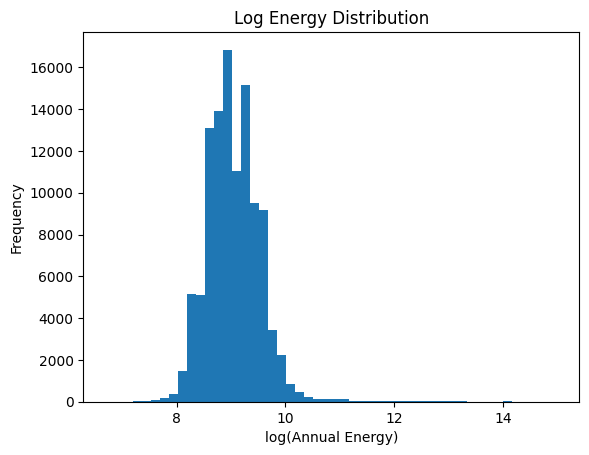

In [35]:
# Target Variable Analysis

# Distribution (Original)

plt.figure()
plt.hist(df['log_energy'], bins=50)
plt.title("Log Energy Distribution")
plt.xlabel("log(Annual Energy)")
plt.ylabel("Frequency")
plt.show()

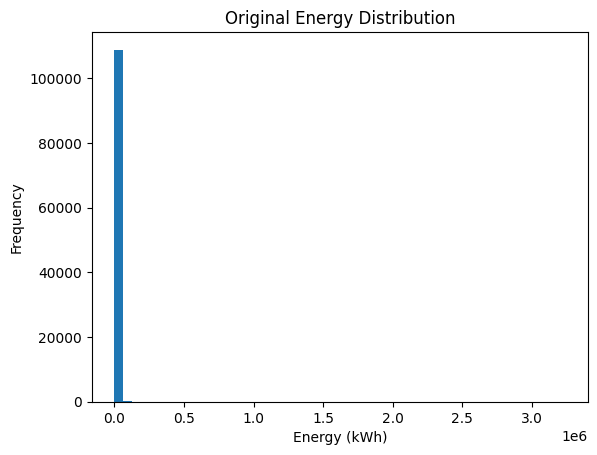

In [36]:
# Back-transform Visualization

plt.figure()
plt.hist(np.expm1(df['log_energy']), bins=50)
plt.title("Original Energy Distribution")
plt.xlabel("Energy (kWh)")
plt.ylabel("Frequency")
plt.show()


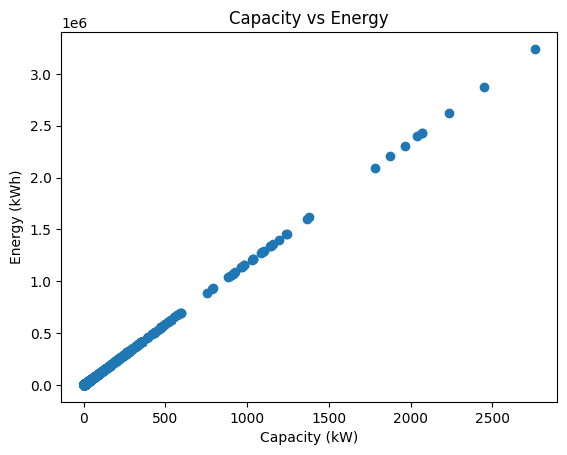

In [37]:
# Capacity vs Energy

plt.figure()
plt.scatter(df['capacity_kw'], np.expm1(df['log_energy']))
plt.xlabel("Capacity (kW)")
plt.ylabel("Energy (kWh)")
plt.title("Capacity vs Energy")
plt.show()

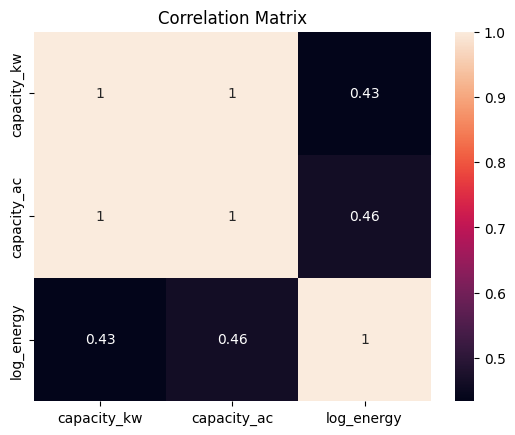

In [38]:
# Correlation Analysis

corr = df[['capacity_kw','capacity_ac','log_energy']].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

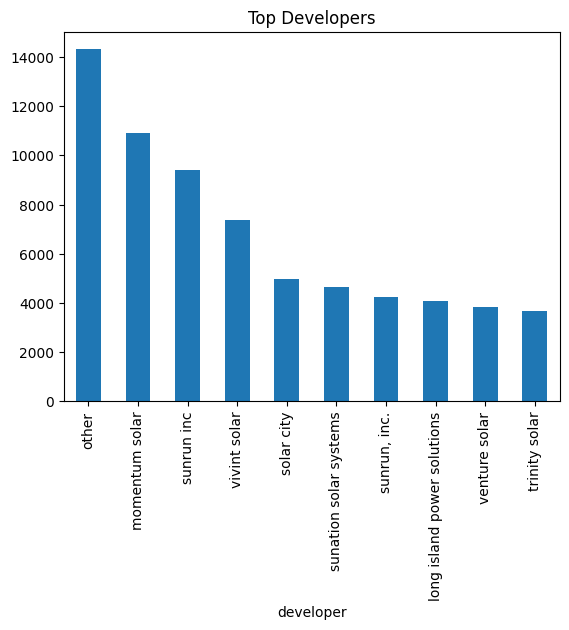

In [39]:
# Categorical Feature Analysis - Top Developers

top_dev = df['developer'].value_counts().head(10)

top_dev.plot(kind='bar')
plt.title("Top Developers")
plt.show()

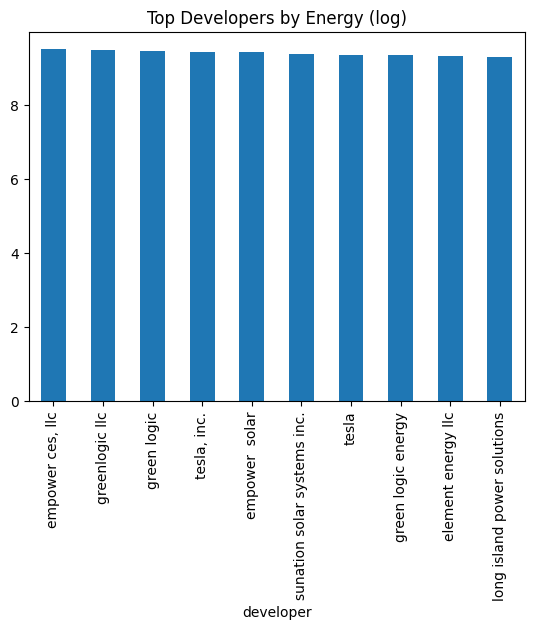

In [40]:
# Developer Vs Energy

dev_energy = df.groupby('developer')['log_energy'].mean().sort_values(ascending=False).head(10)

dev_energy.plot(kind='bar')
plt.title("Top Developers by Energy (log)")
plt.show()

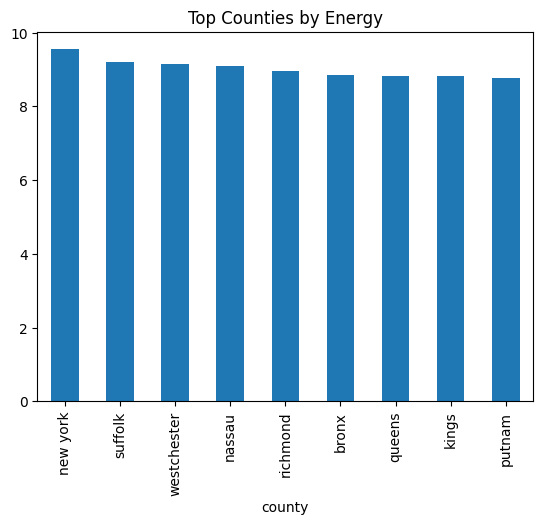

In [41]:
# County Analysis

county_energy = df.groupby('county')['log_energy'].mean().sort_values(ascending=False).head(10)

county_energy.plot(kind='bar')
plt.title("Top Counties by Energy")
plt.show()

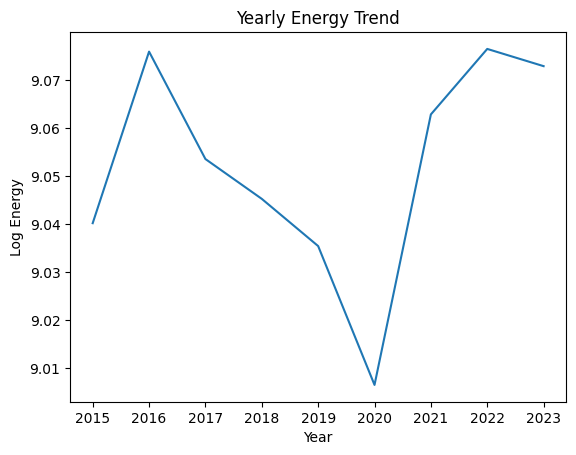

In [42]:
# Time-Based Analysis - Yearly Trend

yearly = df.groupby('year')['log_energy'].mean()

yearly.plot()
plt.title("Yearly Energy Trend")
plt.xlabel("Year")
plt.ylabel("Log Energy")
plt.show()

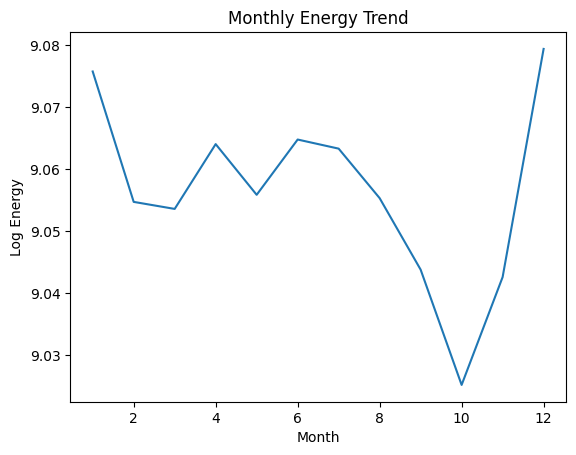

In [43]:
# Monthly Trend

monthly = df.groupby('month')['log_energy'].mean()

monthly.plot()
plt.title("Monthly Energy Trend")
plt.xlabel("Month")
plt.ylabel("Log Energy")
plt.show()

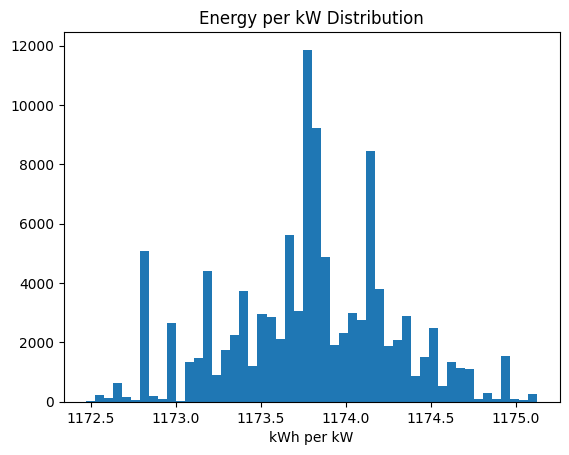

In [44]:
# Recreate annual_energy from log_energy
df['annual_energy'] = np.expm1(df['log_energy'])

# Recreate energy_per_kw
df['energy_per_kw'] = df['annual_energy'] / df['capacity_kw']

# Efficiency Analysis

# Energy per kW Distribution

plt.figure()
plt.hist(df['energy_per_kw'], bins=50)
plt.title("Energy per kW Distribution")
plt.xlabel("kWh per kW")
plt.show()

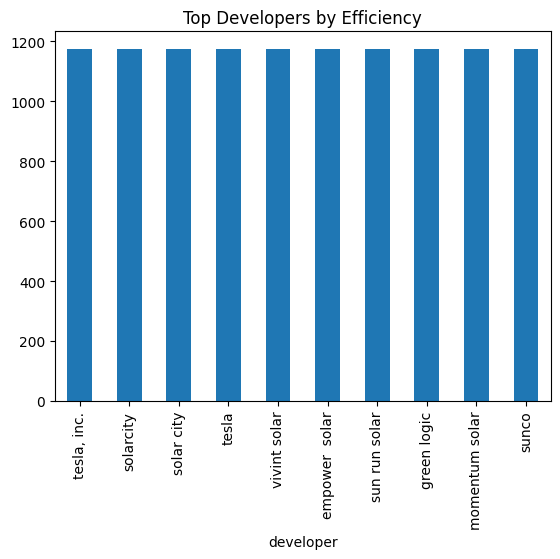

In [45]:
# Developer Efficiency

dev_eff = df.groupby('developer')['energy_per_kw'].mean().sort_values(ascending=False).head(10)

dev_eff.plot(kind='bar')
plt.title("Top Developers by Efficiency")
plt.show()

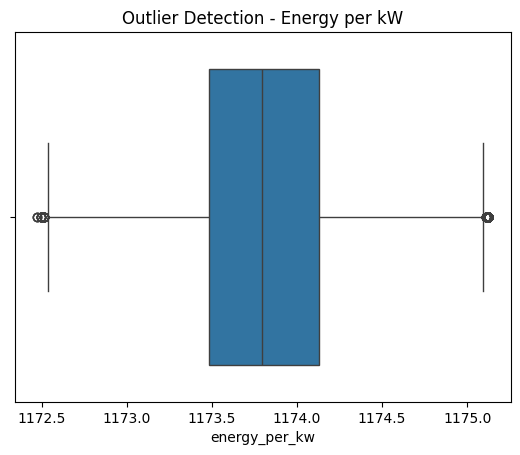

In [46]:
# Outlier Visualization

plt.figure()
sns.boxplot(x=df['energy_per_kw'])
plt.title("Outlier Detection - Energy per kW")
plt.show()

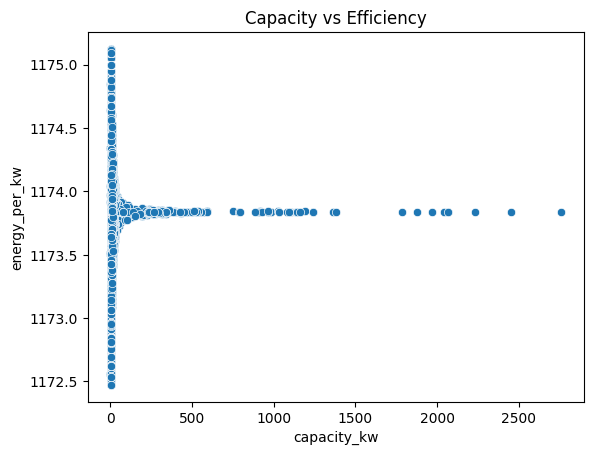

In [47]:
# Feature Interaction

sns.scatterplot(
    x=df['capacity_kw'],
    y=df['energy_per_kw']
)
plt.title("Capacity vs Efficiency")
plt.show()

In [48]:
# Key Insight Extraction

print("Correlation (capacity vs energy):", df['capacity_kw'].corr(np.expm1(df['log_energy'])))

print("\nTop Developers by Efficiency:")
print(df.groupby('developer')['energy_per_kw'].mean().sort_values(ascending=False).head())

print("\nTop Counties by Efficiency:")
print(df.groupby('county')['energy_per_kw'].mean().sort_values(ascending=False).head())

Correlation (capacity vs energy): 0.9999999959953282

Top Developers by Efficiency:
developer
tesla, inc.     1174.015905
solarcity       1173.926200
solar city      1173.905952
tesla           1173.881000
vivint solar    1173.873811
Name: energy_per_kw, dtype: float64

Top Counties by Efficiency:
county
suffolk        1173.832064
nassau         1173.816187
new york       1173.808527
kings          1173.781982
westchester    1173.779200
Name: energy_per_kw, dtype: float64


## Define Features & Target

In [49]:
# Recreate 'annual_energy' from 'log_energy' if needed for other computations
df['annual_energy'] = np.expm1(df['log_energy'])

# Recreate 'energy_per_kw' for potential use, but it's not the target here
df['energy_per_kw'] = df['annual_energy'] / df['capacity_kw']

# The target for prediction should be 'log_energy' to leverage the log transformation.
target = 'log_energy'


In [50]:
features = [
    'developer',
    'county',
    'city',
    'Utility',
    'Metering Method',
    'capacity_kw', # Add capacity_kw back as a feature when predicting log_energy
    'year',
    'month'
]

X = df[features]
y = df['log_energy'] # Explicitly assign y to df['log_energy'] as intended for log-transformed prediction


In [51]:
# Handle Outliers

Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mask = (y >= lower) & (y <= upper)

X = X[mask]
y = y[mask]


In [52]:
# Column Separation

cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(include=['int64','float64']).columns


In [53]:
# Preprocessing Pipeline

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])


In [54]:
# Train- Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Model Selection

In [55]:
# Define Models

models = {
    "Linear": LinearRegression(),

    "RandomForest": RandomForestRegressor(n_estimators=100,max_depth=10,random_state=42),

    "GradientBoosting": GradientBoostingRegressor(random_state=42),

    "XGBoost": XGBRegressor(n_estimators=200,learning_rate=0.1,max_depth=6,random_state=42)
}


## Model Training & Validation

In [56]:
# Baseline Model Comparison (Cross Validation)

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring='neg_mean_absolute_error'
    )

    mae = -scores.mean()

    results.append((name, mae))
    print(f"{name}: MAE = {mae:.4f}")


Linear: MAE = 0.0841
RandomForest: MAE = 0.0001
GradientBoosting: MAE = 0.0015
XGBoost: MAE = 0.0019


## Model Comparison

In [76]:
results_df = pd.DataFrame(results, columns=['Model', 'MAE'])
print(results_df.sort_values(by='MAE'))


              Model       MAE
1      RandomForest  0.000054
2  GradientBoosting  0.001508
3           XGBoost  0.001890
0            Linear  0.084142


# Hyperparamter Tuning

In [58]:
rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_params = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, 15],
    'model__min_samples_split': [2, 5, 10]
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    n_iter=5,
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best RF Params:", rf_search.best_params_)


Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best RF Params: {'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__max_depth': 15}


In [59]:
# Select Best Model
best_model =  rf_search.best_estimator_


## Train Best Model

In [60]:
# The `best_model` variable already holds the best performing pipeline from `rf_search.best_estimator_` (tuned RandomForest).
# This pipeline already contains the preprocessor and the best-tuned RandomForestRegressor.
# Therefore, we should directly use this `best_model` as our `final_pipeline`.
final_pipeline = best_model

# We set best_model_name for print statements later.
# Since rf_search was used to tune RandomForest, we know the best model type.
best_model_name = "RandomForest (Tuned)"

# Fit the final pipeline (which is the best_model pipeline) on the training data.
final_pipeline.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['capacity_kw', 'year', 'month'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['developer', 'county', 'city', 'Utility', 'Metering Method'], dtype='object'))])),
                ('model',
                 RandomForestRegressor(max_depth=15, min_samples_split=5,
                                       n_estimators=200, random_state=42))])

## Evaluate on Test Data

In [61]:
y_pred = final_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Final Model:", best_model_name)
print("Test MAE:", mae)
print("R2 Score:", r2)


Final Model: RandomForest (Tuned)
Test MAE: 1.3410351032332874e-05
R2 Score: 0.9999999077690888


## Convert Back to Actual Scale

In [62]:
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

mae_actual = mean_absolute_error(y_test_actual, y_pred_actual)

print("MAE (actual kWh):", mae_actual)


MAE (actual kWh): 0.15027201607468857


# Save Final Model

In [63]:
joblib.dump(final_pipeline, "final_solar_model.pkl")


['final_solar_model.pkl']

## Shap Explainability pipeline

In [64]:
pip install shap

In [65]:
import shap

## Load Model & Data

In [66]:
import joblib

model = joblib.load("final_solar_model.pkl")

df = pd.read_csv("solar_cleaned_preprocessed.csv")

X = df.drop(columns=['log_energy'])
y = df['log_energy'] # Ensure y is correctly set for SHAP data


/tmp/ipykernel_3436/3855309308.py:5: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("solar_cleaned_preprocessed.csv")


## Sample Data (SHAP can be slow or large data)

In [67]:
X_sample = X.sample(2000, random_state=42)


In [68]:
# Extract Preprocessed Data
# Separate preprocessing + model
preprocessor = model.named_steps['prep']
trained_model = model.named_steps['model']

X_processed = preprocessor.transform(X_sample)


In [69]:
# Create SHAP Explainer
explainer = shap.TreeExplainer(trained_model)
# Convert sparse matrix to dense array if it is sparse
if hasattr(X_processed, 'toarray'):
    X_processed = X_processed.toarray()
shap_values = explainer.shap_values(X_processed)


In [70]:
# Get Feature Names
feature_names = preprocessor.get_feature_names_out()


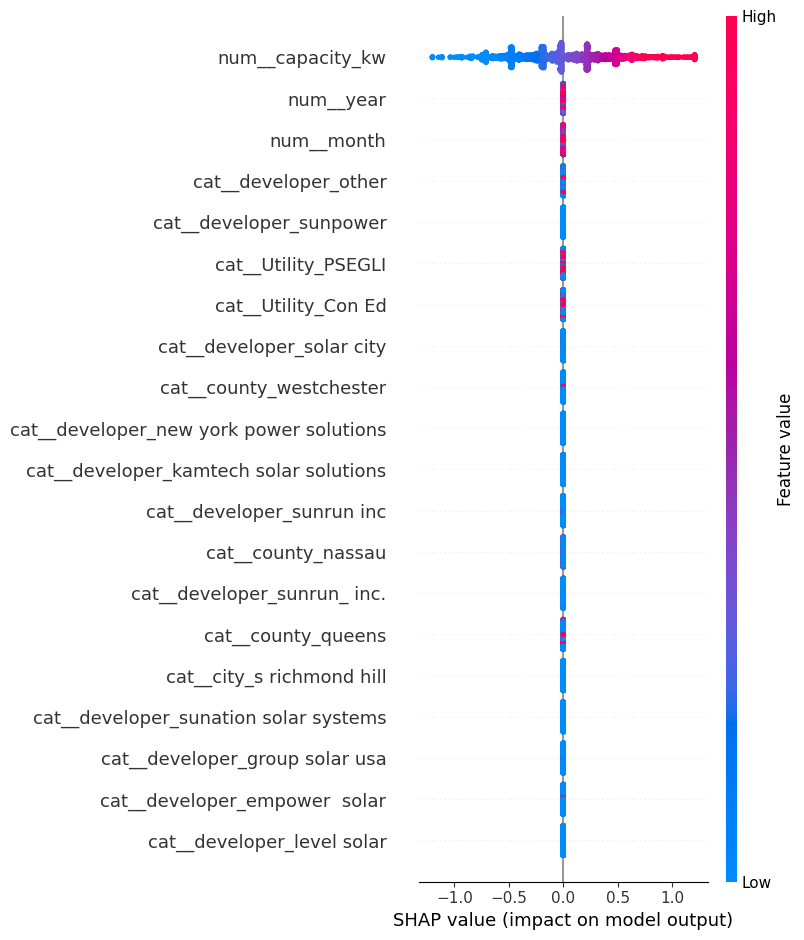

In [71]:
# Global Feature Importance
shap.summary_plot(shap_values, X_processed, feature_names=feature_names)


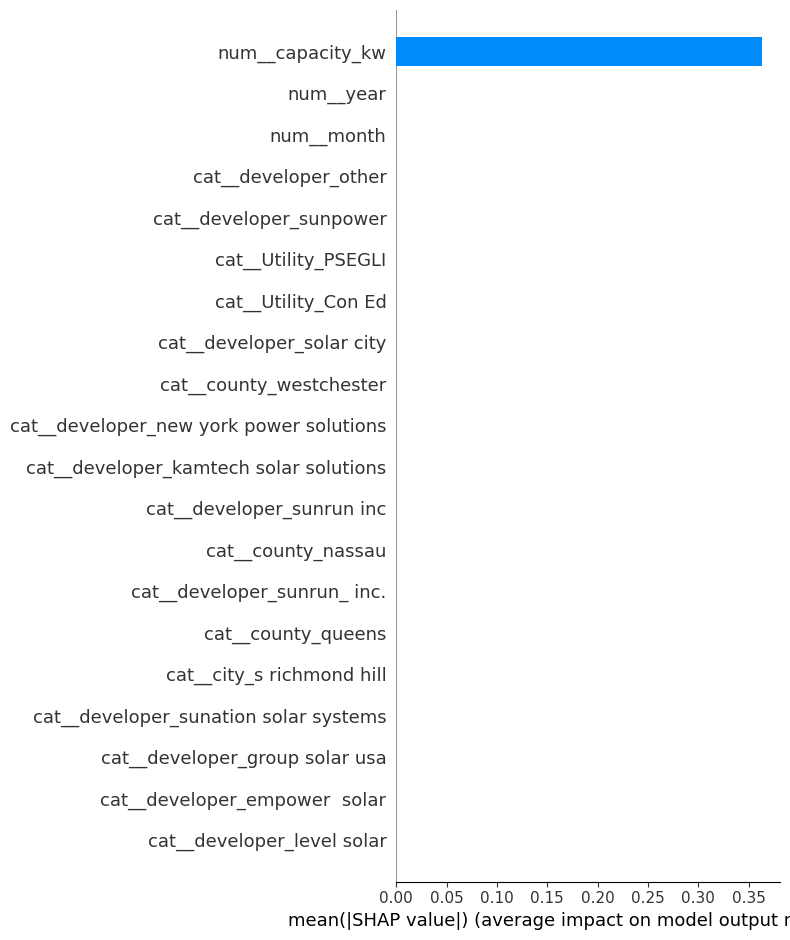

In [72]:
# Bar Plot
shap.summary_plot(shap_values, X_processed, feature_names=feature_names, plot_type="bar")


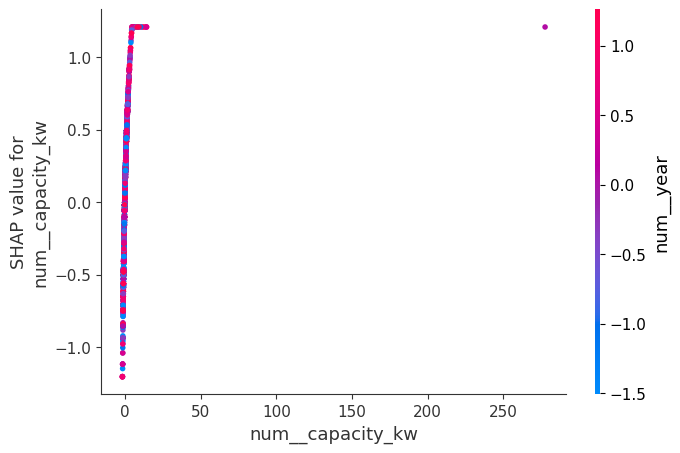

In [73]:
# Feature Impact
shap.dependence_plot(
    "num__capacity_kw",
    shap_values,
    X_processed,
    feature_names=feature_names
)


In [74]:
# Individual Prediction Explanation
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    feature_names=feature_names
)


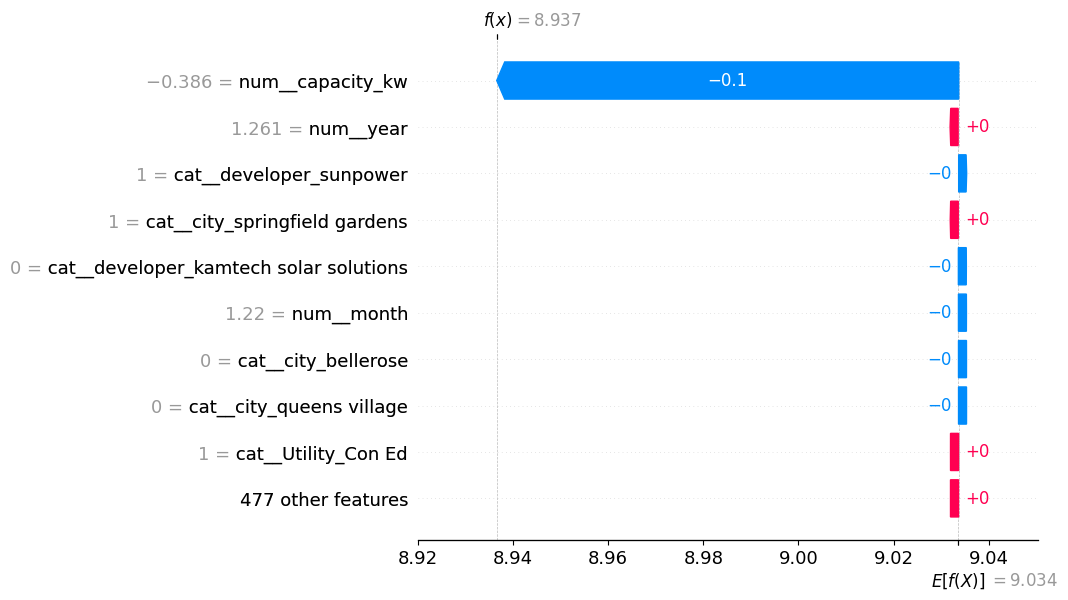

In [75]:
# Waterfall Plot
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_processed[0],
        feature_names=feature_names
    )
)
